# Practica de Machine Learning - Random Forest Classifier
## Clasificacion de Enfermedad Cardiaca
### Dataset: Heart Disease (UCI Machine Learning Repository)

**Alumno:** Angel Geovanny Alvarez Ordinola  
**Algoritmo:** Random Forest Classifier  
**Problema:** Clasificacion Binaria

## Seccion 1 - Librerias

In [2]:
# ============================================================
# CELDA 0: INSTALACION DE DEPENDENCIAS
# ============================================================
# Verifica e instala las librerias si no estan disponibles.
# Es seguro ejecutarla multiples veces.
import importlib
import subprocess
import sys

paquetes_requeridos = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn'
}

for modulo, paquete in paquetes_requeridos.items():
    if importlib.util.find_spec(modulo) is None:
        print(f'Instalando {paquete}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', paquete])
    else:
        print(f'OK  {paquete}')

print('\nTodas las dependencias estan listas.')

OK  pandas
OK  numpy
OK  matplotlib
OK  seaborn
OK  scikit-learn

Todas las dependencias estan listas.


In [3]:
# ============================================================
# SECCION 1: IMPORTACION DE LIBRERIAS
# ============================================================
# Todas las librerias necesarias se importan aqui al inicio
# para mantener el codigo organizado y claro.

# Manipulacion y analisis de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning: Pipeline
from sklearn.pipeline import Pipeline

# Machine Learning: Modelo principal
from sklearn.ensemble import RandomForestClassifier

# Machine Learning: Metricas de evaluacion
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Semilla global para reproducibilidad en todos los pasos
RANDOM_STATE = 42

# Configuracion de estilo para todas las graficas del notebook
try:
    # seaborn >= 0.11
    sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
except AttributeError:
    # seaborn < 0.11 (fallback compatible)
    sns.set(style='whitegrid', palette='muted', font_scale=1.1)

plt.rcParams['figure.figsize'] = (10, 6)

print('Todas las librerias importadas correctamente.')
print(f'pandas     {pd.__version__}')
print(f'numpy      {np.__version__}')
print(f'seaborn    {sns.__version__}')
import sklearn
print(f'scikit-learn {sklearn.__version__}')

Todas las librerias importadas correctamente.
pandas     3.0.3
numpy      2.4.6
seaborn    0.13.2
scikit-learn 1.9.0


## Seccion 2 - Dataset

In [4]:
# ============================================================
# SECCION 2: CARGA DEL DATASET
# ============================================================
#
# ORIGEN DEL DATASET:
#   Heart Disease Dataset - UCI Machine Learning Repository
#   URL: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
#   Tambien disponible en Kaggle:
#   https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
#
# VARIABLE OBJETIVO (target):
#   target -> 1 = paciente TIENE enfermedad cardiaca
#             0 = paciente NO tiene enfermedad cardiaca
#
# SIGNIFICADO DE VARIABLES:
#   age        -> Edad del paciente en anyos
#   sex        -> Sexo (1=masculino, 0=femenino)
#   cp         -> Tipo de dolor en el pecho:
#                 0=angina tipica, 1=angina atipica,
#                 2=dolor no anginoso, 3=asintomatico
#   trestbps   -> Presion arterial en reposo (mm Hg)
#   chol       -> Colesterol serico (mg/dl)
#   fbs        -> Azucar en sangre en ayunas > 120 mg/dl (1=Si, 0=No)
#   restecg    -> Resultados del electrocardiograma en reposo
#                 (0=normal, 1=anormalidad ST-T, 2=hipertrofia ventricular)
#   thalach    -> Frecuencia cardiaca maxima alcanzada
#   exang      -> Angina inducida por ejercicio (1=Si, 0=No)
#   oldpeak    -> Depresion del segmento ST inducida por ejercicio
#   slope      -> Pendiente del pico del segmento ST
#                 (0=ascendente, 1=plana, 2=descendente)
#   ca         -> Numero de vasos principales (0-3) coloreados
#   thal       -> Resultado de la prueba de talasemia:
#                 1=defecto fijo, 2=normal, 3=defecto reversible
#   target     -> VARIABLE OBJETIVO (1=Enfermedad, 0=Sin enfermedad)

# URL publica del dataset (mirror de UCI/Kaggle en GitHub)
DATA_URL = 'heart.csv'  # archivo local descargado

# Carga del dataset en un DataFrame de pandas
df = pd.read_csv(DATA_URL)

print(f'Dataset cargado exitosamente.')
print(f'Registros: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado exitosamente.
Registros: 303 filas x 14 columnas


In [5]:
# Primeras 5 filas: verifica estructura y nombres de columnas
print('--- PRIMERAS 5 FILAS DEL DATASET ---')
df.head()

--- PRIMERAS 5 FILAS DEL DATASET ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
# Dimensiones del dataset: (filas, columnas)
print(f'Dimensiones: {df.shape}')

Dimensiones: (303, 14)


In [7]:
# info() muestra tipos de datos y conteo de no-nulos por columna
print('--- INFORMACION GENERAL ---')
df.info()

--- INFORMACION GENERAL ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
# describe() muestra estadisticas descriptivas: media, std, percentiles
print('--- ESTADISTICAS DESCRIPTIVAS ---')
df.describe().round(2)

--- ESTADISTICAS DESCRIPTIVAS ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## Seccion 3 - Exploracion (EDA)

C:\Users\geova\AppData\Local\Temp\ipykernel_2616\99199601.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


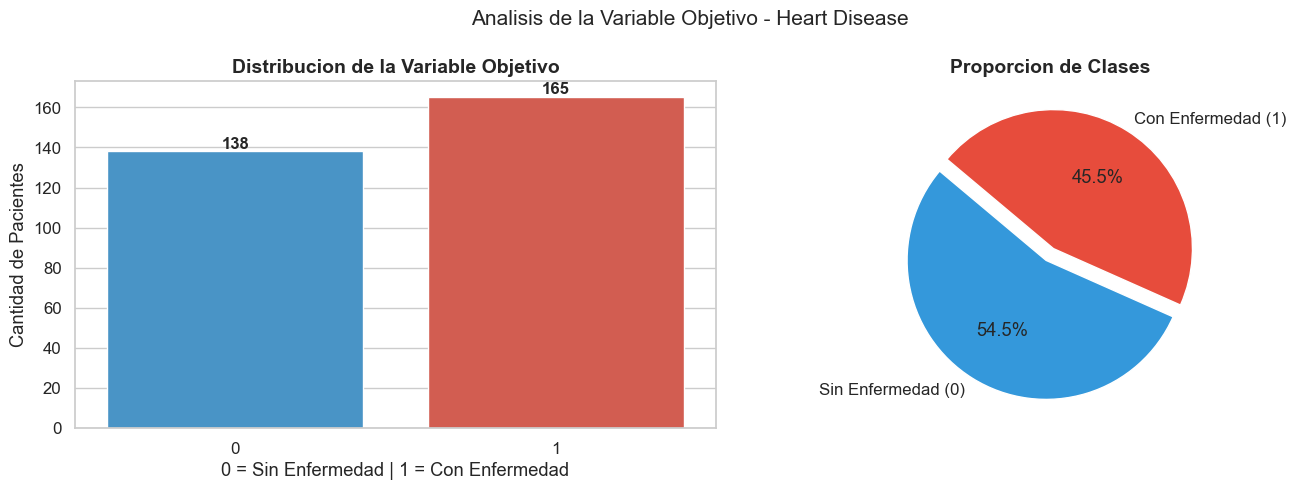

Clase 0 (Sin Enfermedad): 138 pacientes (45.5%)
Clase 1 (Con Enfermedad): 165 pacientes (54.5%)
Dataset relativamente balanceado. No se requiere rebalanceo.


In [9]:
# ============================================================
# SECCION 3: ANALISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================

# 3.1 Distribucion de la Variable Objetivo
# Conocer el balance de clases es fundamental antes de entrenar.
# Un desbalance severo puede requerir tecnicas especiales.

conteo_target = df['target'].value_counts()
etiquetas_target = ['Sin Enfermedad (0)', 'Con Enfermedad (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica de barras
sns.countplot(
    x='target',
    data=df,
    ax=axes[0],
    palette=['#3498db', '#e74c3c'],
    order=[0, 1]
)
axes[0].set_title('Distribucion de la Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('0 = Sin Enfermedad | 1 = Con Enfermedad')
axes[0].set_ylabel('Cantidad de Pacientes')
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# Grafica de pastel
axes[1].pie(
    conteo_target,
    labels=etiquetas_target,
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=140,
    explode=(0.05, 0.05)
)
axes[1].set_title('Proporcion de Clases', fontsize=14, fontweight='bold')

plt.suptitle('Analisis de la Variable Objetivo - Heart Disease', fontsize=15)
plt.tight_layout()
plt.show()

print(f'Clase 0 (Sin Enfermedad): {conteo_target[0]} pacientes '
      f'({conteo_target[0]/len(df)*100:.1f}%)')
print(f'Clase 1 (Con Enfermedad): {conteo_target[1]} pacientes '
      f'({conteo_target[1]/len(df)*100:.1f}%)')
print('Dataset relativamente balanceado. No se requiere rebalanceo.')

In [10]:
# 3.2 Busqueda de Valores Nulos
# Los valores nulos pueden afectar el rendimiento del modelo.

valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

reporte_nulos = pd.DataFrame({
    'Valores_Nulos': valores_nulos,
    'Porcentaje_%': porcentaje_nulos
})

print('--- REPORTE DE VALORES NULOS ---')
print(reporte_nulos)
print(f'\nTotal de celdas con valores nulos: {df.isnull().sum().sum()}')

--- REPORTE DE VALORES NULOS ---
          Valores_Nulos  Porcentaje_%
age                   0           0.0
sex                   0           0.0
cp                    0           0.0
trestbps              0           0.0
chol                  0           0.0
fbs                   0           0.0
restecg               0           0.0
thalach               0           0.0
exang                 0           0.0
oldpeak               0           0.0
slope                 0           0.0
ca                    0           0.0
thal                  0           0.0
target                0           0.0

Total de celdas con valores nulos: 0


In [11]:
# 3.3 Busqueda de Duplicados
# Los registros duplicados pueden sesgar el modelo.

num_duplicados = df.duplicated().sum()
print(f'Numero de filas duplicadas: {num_duplicados}')

if num_duplicados > 0:
    print(f'Se encontraron {num_duplicados} duplicados. Se eliminaran.')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicados eliminados. Nuevo shape: {df.shape}')
else:
    print('No existen filas duplicadas.')

Numero de filas duplicadas: 1
Se encontraron 1 duplicados. Se eliminaran.
Duplicados eliminados. Nuevo shape: (302, 14)


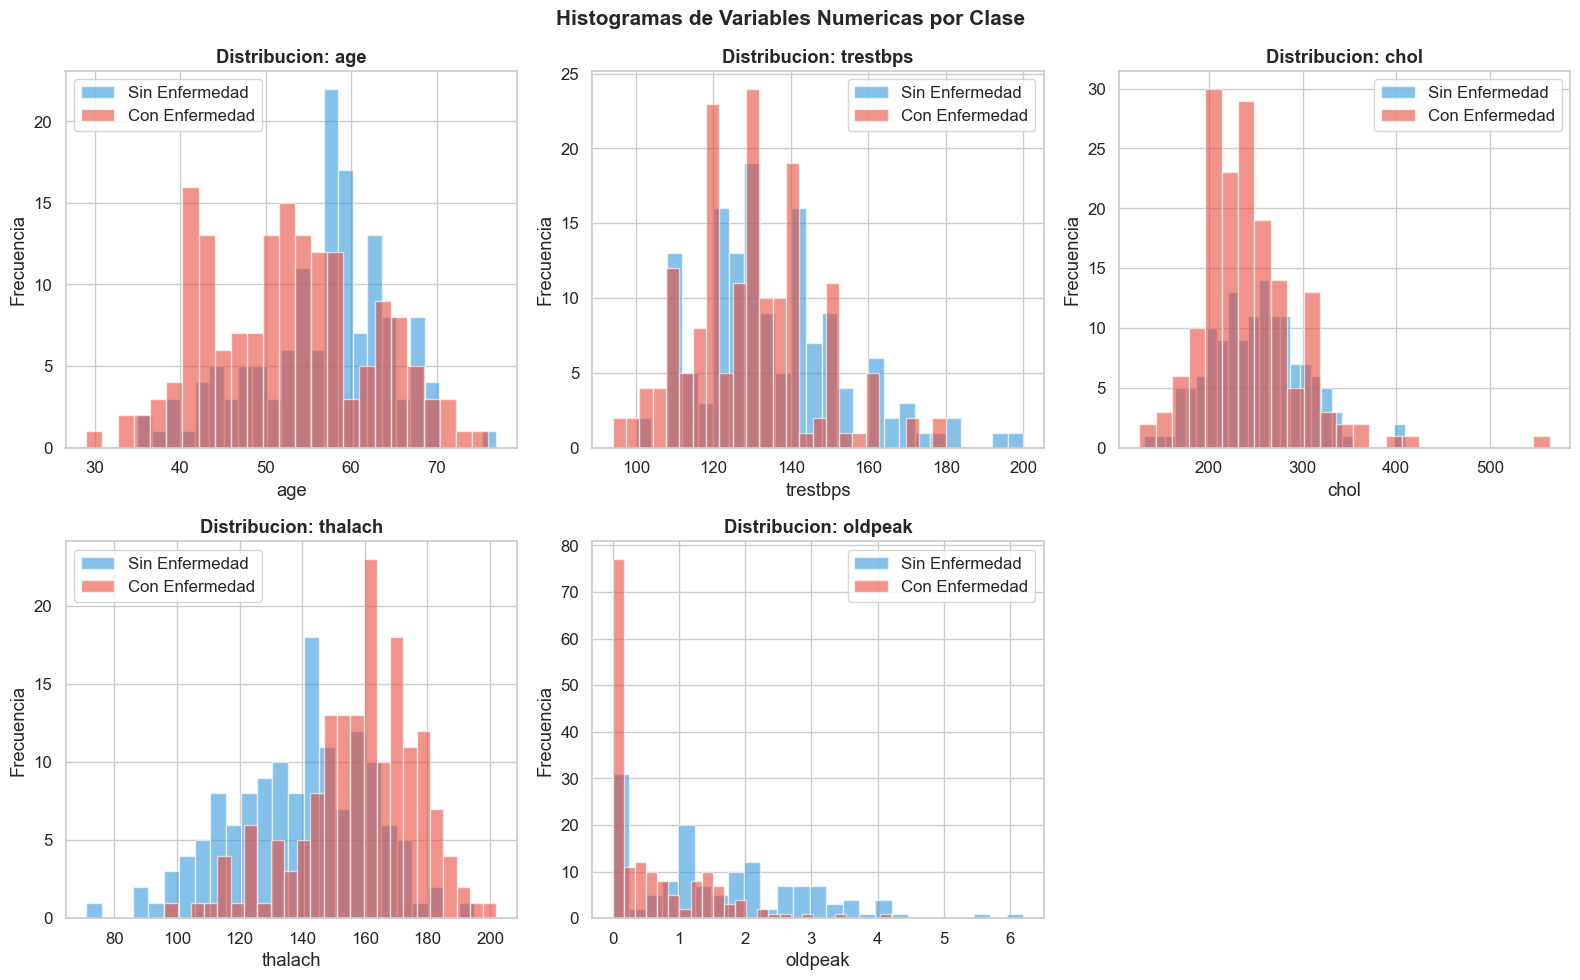

Azul = Sin Enfermedad | Rojo = Con Enfermedad


In [12]:
# 3.4 Histogramas de Variables Numericas
# Muestran la distribucion de frecuencias y permiten
# identificar asimetrias, bimodalidades y rangos.

columnas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    # Separamos por clase para ver diferencias de distribucion
    df[df['target'] == 0][col].hist(
        ax=axes[i], bins=25, alpha=0.6,
        color='#3498db', label='Sin Enfermedad'
    )
    df[df['target'] == 1][col].hist(
        ax=axes[i], bins=25, alpha=0.6,
        color='#e74c3c', label='Con Enfermedad'
    )
    axes[i].set_title(f'Distribucion: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

axes[-1].set_visible(False)

plt.suptitle('Histogramas de Variables Numericas por Clase',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Azul = Sin Enfermedad | Rojo = Con Enfermedad')

C:\Users\geova\AppData\Local\Temp\ipykernel_2616\2274810412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\geova\AppData\Local\Temp\ipykernel_2616\2274810412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\geova\AppData\Local\Temp\ipykernel_2616\2274810412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\geova\AppData\Local\Temp\ipykernel_2616\2274810412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

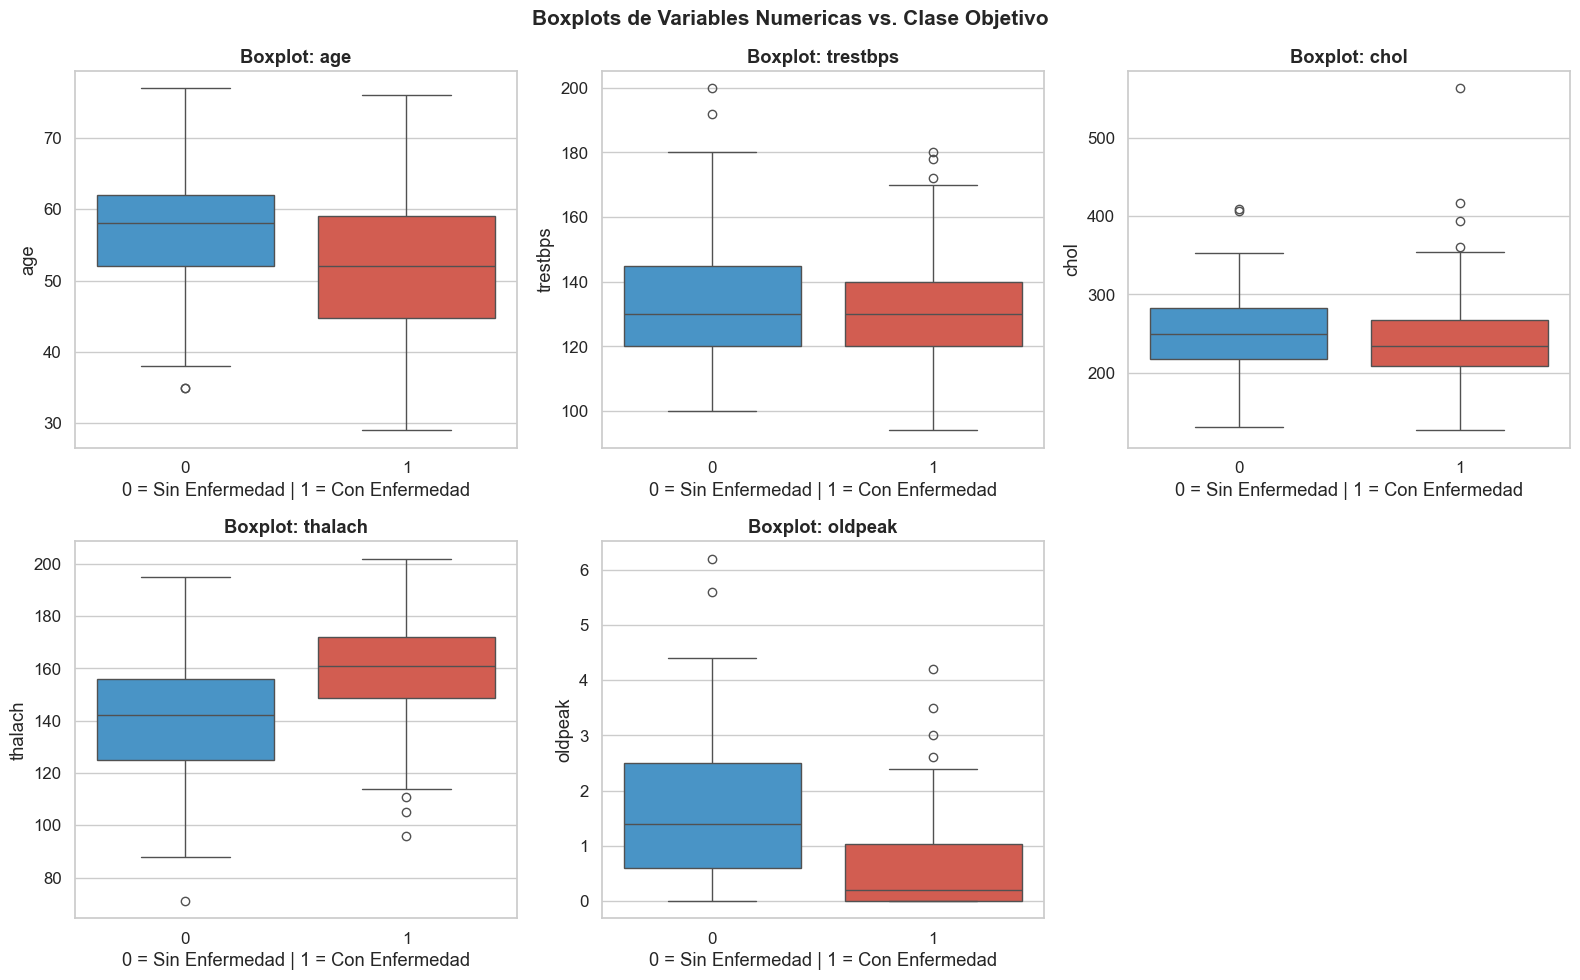

Random Forest es robusto frente a outliers.


In [14]:
# 3.5 Boxplots - Deteccion de Valores Atipicos
# Los boxplots muestran la mediana, rango intercuartilico (IQR)
# y los valores atipicos (outliers) como puntos fuera de los bigotes.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(
        x='target', y=col,
        data=df, ax=axes[i],
        palette={'0': '#3498db', '1': '#e74c3c'}
    )
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_xlabel('0 = Sin Enfermedad | 1 = Con Enfermedad')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle('Boxplots de Variables Numericas vs. Clase Objetivo',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Random Forest es robusto frente a outliers.')

In [15]:
# 3.6 Identificacion Cuantitativa de Outliers (Metodo IQR)
# Outlier: valor < Q1 - 1.5*IQR  o  valor > Q3 + 1.5*IQR

print('--- CONTEO DE OUTLIERS POR VARIABLE (Metodo IQR) ---')
for col in columnas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    print(f'  {col:12s}: {n_outliers:3d} outliers '
          f'(rango valido: [{lim_inf:.2f}, {lim_sup:.2f}])')

print('\nRandom Forest no requiere eliminar outliers.')

--- CONTEO DE OUTLIERS POR VARIABLE (Metodo IQR) ---
  age         :   0 outliers (rango valido: [28.50, 80.50])
  trestbps    :   9 outliers (rango valido: [90.00, 170.00])
  chol        :   5 outliers (rango valido: [115.38, 370.38])
  thalach     :   1 outliers (rango valido: [84.12, 215.12])
  oldpeak     :   5 outliers (rango valido: [-2.40, 4.00])

Random Forest no requiere eliminar outliers.


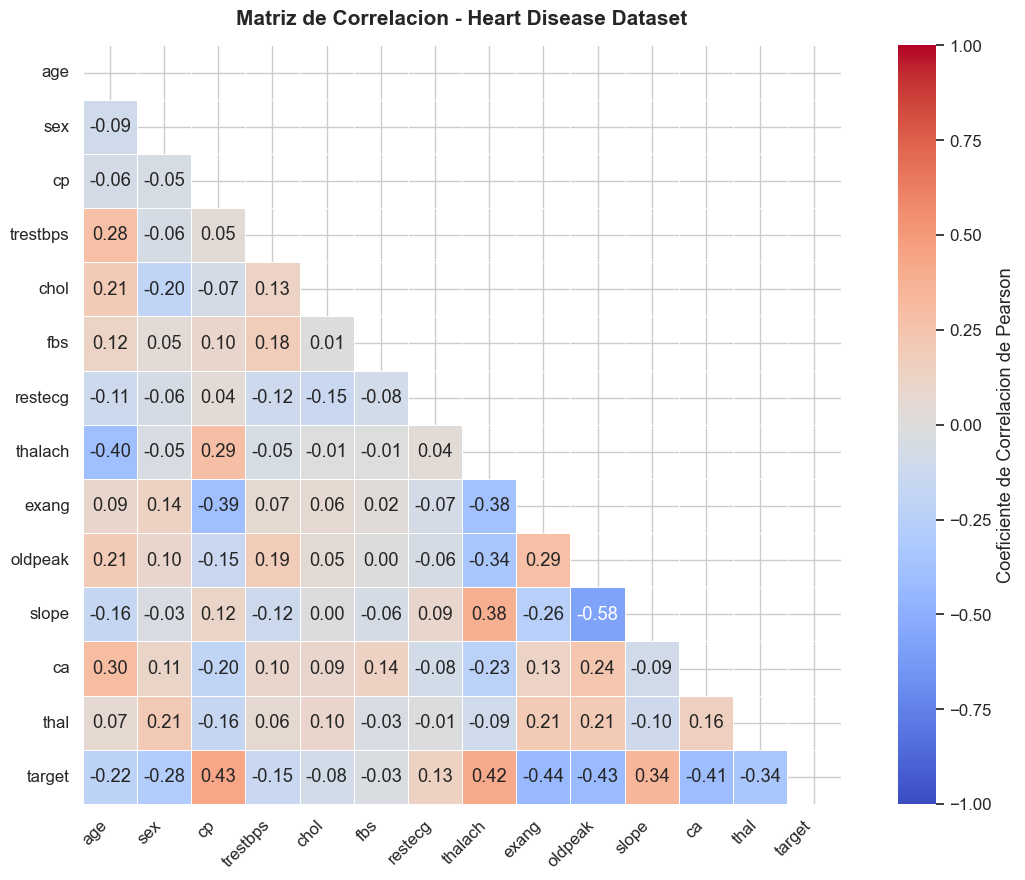

--- CORRELACION CON LA VARIABLE OBJETIVO (target) ---
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601


In [16]:
# 3.7 Matriz de Correlacion y Heatmap
# Correlacion de Pearson: mide relacion lineal entre variables.
# Cercano a +1/-1 = fuerte correlacion. Cercano a 0 = poca correlacion.

correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
# Mascara para mostrar solo el triangulo inferior
mascara = np.triu(np.ones_like(correlacion, dtype=bool))

sns.heatmap(
    correlacion,
    mask=mascara,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Coeficiente de Correlacion de Pearson'}
)

plt.title('Matriz de Correlacion - Heart Disease Dataset',
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlacion de cada variable con la variable objetivo
print('--- CORRELACION CON LA VARIABLE OBJETIVO (target) ---')
corr_target = correlacion['target'].drop('target').sort_values(ascending=False)
print(corr_target.to_string())

## Seccion 4 - Limpieza

In [17]:
# ============================================================
# SECCION 4: LIMPIEZA DE DATOS
# ============================================================

# Verificacion final de valores nulos
assert df.isnull().sum().sum() == 0, 'ERROR: Existen valores nulos sin tratar.'
print(f'Confirmado: 0 valores nulos en el dataset.')

# Verificacion de tipos de datos
print(f'\nTipos de datos por columna:')
print(df.dtypes.to_string())

# Verificacion de rango de la variable objetivo
assert set(df['target'].unique()).issubset({0, 1}), (
    'ERROR: target contiene valores inesperados.'
)
print(f'\nVariable objetivo correcta. Valores unicos: {sorted(df["target"].unique())}')

# Variables categoricas ya codificadas como enteros
# Random Forest puede manejarlas directamente
vars_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print(f'\nVariables categoricas codificadas como int: {vars_cat}')
print(f'\nLimpieza completada. Shape final: {df.shape}')

Confirmado: 0 valores nulos en el dataset.

Tipos de datos por columna:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64

Variable objetivo correcta. Valores unicos: [np.int64(0), np.int64(1)]

Variables categoricas codificadas como int: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Limpieza completada. Shape final: (302, 14)


## Seccion 5 - Preprocesamiento

In [18]:
# ============================================================
# SECCION 5: PREPROCESAMIENTO
# ============================================================

# Separacion de Variables Independientes y Variable Objetivo
#   X: todas las columnas excepto 'target'
#   y: columna 'target' (etiqueta a predecir)

COLUMNA_OBJETIVO = 'target'

# Variables independientes
X = df.drop(columns=[COLUMNA_OBJETIVO])

# Variable dependiente
y = df[COLUMNA_OBJETIVO]

print('Separacion completada:')
print(f'  X (variables independientes): {X.shape}')
print(f'  Columnas: {list(X.columns)}')
print(f'  y (variable objetivo):        {y.shape}')
print(f'  Valores unicos en y: {sorted(y.unique())}')

# Nota sobre Escalado:
# Random Forest NO requiere escalado porque esta basado en arboles
# que realizan cortes sobre valores individuales, no distancias.
# Se incluira StandardScaler en el Pipeline por buena practica.
print('\nNota: Random Forest no requiere escalado obligatorio.')

Separacion completada:
  X (variables independientes): (302, 13)
  Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
  y (variable objetivo):        (302,)
  Valores unicos en y: [np.int64(0), np.int64(1)]

Nota: Random Forest no requiere escalado obligatorio.


## Seccion 6 - Division

In [19]:
# ============================================================
# SECCION 6: DIVISION DEL CONJUNTO DE DATOS
# ============================================================
#
# Division 80% entrenamiento / 20% prueba.
#
# Parametros:
#   test_size=0.20   -> 20% para prueba
#   random_state=42  -> Semilla fija para reproducibilidad
#   stratify=y       -> Mantiene la proporcion de clases en ambos
#                       subconjuntos (evita desbalance aleatorio)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Division completada:')
print(f'  X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')

print(f'\nDistribucion en entrenamiento:')
print(y_train.value_counts(normalize=True).round(4).to_string())
print(f'\nDistribucion en prueba:')
print(y_test.value_counts(normalize=True).round(4).to_string())
print('\nLa estratificacion garantiza proporciones similares en ambos sets.')

Division completada:
  X_train: (241, 13)  |  y_train: (241,)
  X_test:  (61, 13)   |  y_test:  (61,)

Distribucion en entrenamiento:
target
1    0.5436
0    0.4564

Distribucion en prueba:
target
1    0.541
0    0.459

La estratificacion garantiza proporciones similares en ambos sets.


## Seccion 7 - Pipeline

In [20]:
# ============================================================
# SECCION 7: CONSTRUCCION DEL PIPELINE
# ============================================================
#
# Un Pipeline encadena pasos de transformacion y el modelo final.
# Ventajas:
#   - Previene Data Leakage: las transformaciones se aprenden
#     SOLO en X_train y se aplican sin re-ajuste en X_test.
#   - Codigo limpio y reproducible.
#
# ESTRUCTURA:
#   Paso 1: imputer -> SimpleImputer (por robustez)
#   Paso 2: scaler  -> StandardScaler
#   Paso 3: clf     -> RandomForestClassifier
#
# HIPERPARAMETROS DE RANDOM FOREST:
#
#   n_estimators=200
#     Numero de arboles en el bosque.
#     Mas arboles = mayor estabilidad. 200 es un valor estandar.
#
#   max_depth=8
#     Profundidad maxima de cada arbol.
#     Limita la complejidad y previene overfitting.
#
#   min_samples_split=5
#     Minimo de muestras para dividir un nodo.
#     Valores mayores generan arboles mas simples.
#
#   min_samples_leaf=2
#     Minimo de muestras en cada hoja terminal.
#     Suaviza el modelo y reduce el sobreajuste.
#
#   max_features='sqrt'
#     Features a considerar al buscar la mejor division.
#     Raiz cuadrada del total de features (criterio estandar RF).
#
#   class_weight='balanced'
#     Ajusta pesos de clase inversamente a su frecuencia.
#
#   random_state=42
#     Semilla para reproducibilidad.
#
#   n_jobs=-1
#     Usa todos los nucleos CPU disponibles.

pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Pipeline construido correctamente.')
print('\nEstructura del Pipeline:')
print(pipeline_rf)

Pipeline construido correctamente.

Estructura del Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


## Seccion 8 - Entrenamiento

In [21]:
# ============================================================
# SECCION 8: ENTRENAMIENTO DEL MODELO
# ============================================================
# El pipeline se ajusta SOLO con datos de entrenamiento.
# Esto garantiza que NO hay data leakage del conjunto de prueba.

print('Entrenando el modelo Random Forest...')

pipeline_rf.fit(X_train, y_train)

print('Modelo entrenado exitosamente.')
print(f'  Arboles entrenados:          {pipeline_rf.named_steps["clf"].n_estimators}')
print(f'  Caracteristicas utilizadas:  {X_train.shape[1]}')
print(f'  Muestras de entrenamiento:   {X_train.shape[0]}')

Entrenando el modelo Random Forest...
Modelo entrenado exitosamente.
  Arboles entrenados:          200
  Caracteristicas utilizadas:  13
  Muestras de entrenamiento:   241


## Seccion 9 - Evaluacion

In [22]:
# ============================================================
# SECCION 9: EVALUACION DEL MODELO
# ============================================================

# Predicciones sobre el set de prueba
# Las predicciones pasan automaticamente por el pipeline completo
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]

# Calcular metricas
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('   METRICAS DE EVALUACION - RANDOM FOREST')
print('=' * 50)
print(f'  Accuracy  (Exactitud):    {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision:                {precision:.4f}')
print(f'  Recall    (Sensibilidad): {recall:.4f}')
print(f'  F1 Score:                 {f1:.4f}')
print(f'  ROC AUC:                  {roc_auc:.4f}')
print('=' * 50)

   METRICAS DE EVALUACION - RANDOM FOREST
  Accuracy  (Exactitud):    0.8197  (81.97%)
  Precision:                0.8346
  Recall    (Sensibilidad): 0.8197
  F1 Score:                 0.8154
  ROC AUC:                  0.9026


In [23]:
# Classification Report: precision, recall y f1 por clase
print('--- CLASSIFICATION REPORT ---')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Sin Enfermedad (0)', 'Con Enfermedad (1)']
))

--- CLASSIFICATION REPORT ---
                    precision    recall  f1-score   support

Sin Enfermedad (0)       0.90      0.68      0.78        28
Con Enfermedad (1)       0.78      0.94      0.85        33

          accuracy                           0.82        61
         macro avg       0.84      0.81      0.81        61
      weighted avg       0.83      0.82      0.82        61



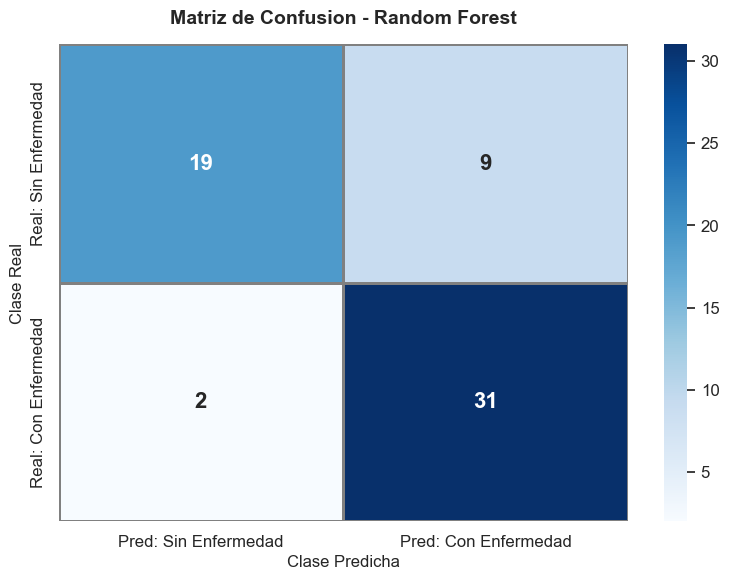

Verdaderos Negativos (TN): 19
Falsos Positivos     (FP): 9
Falsos Negativos     (FN): 2  <- paciente enfermo clasificado como sano
Verdaderos Positivos (TP): 31


In [24]:
# Matriz de Confusion
#   TN: predijo 0, era 0
#   FP: predijo 1, era 0  (Error Tipo I)
#   FN: predijo 0, era 1  (Error Tipo II - critico en medicina)
#   TP: predijo 1, era 1

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: Sin Enfermedad', 'Pred: Con Enfermedad'],
    yticklabels=['Real: Sin Enfermedad', 'Real: Con Enfermedad'],
    linewidths=1,
    linecolor='gray',
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Matriz de Confusion - Random Forest',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = conf_matrix.ravel()
print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos     (FP): {fp}')
print(f'Falsos Negativos     (FN): {fn}  <- paciente enfermo clasificado como sano')
print(f'Verdaderos Positivos (TP): {tp}')

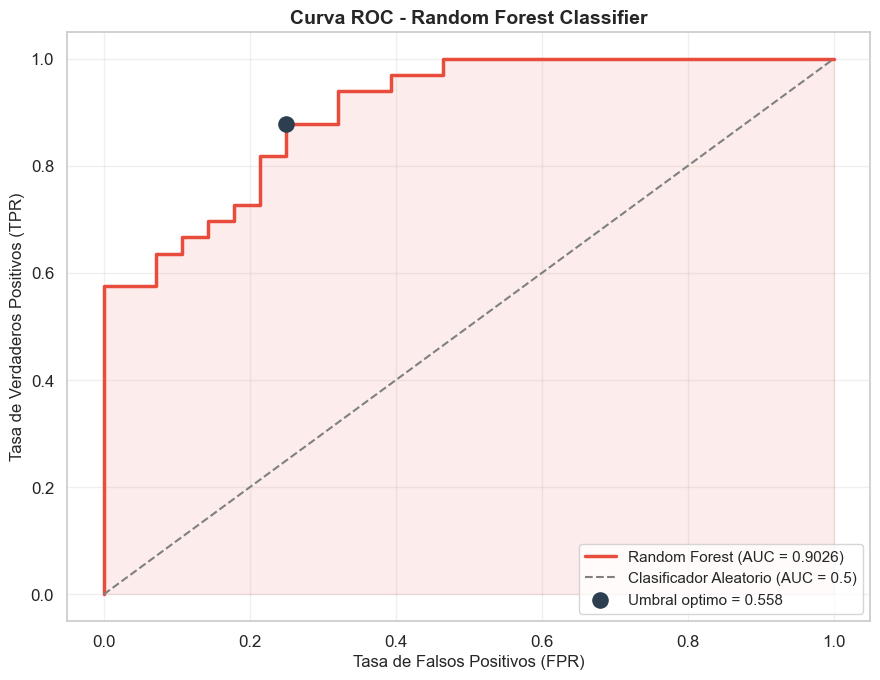

ROC AUC = 0.9026
Umbral optimo (Indice de Youden): 0.5577
TPR en umbral optimo: 0.8788
FPR en umbral optimo: 0.2500


In [25]:
# Curva ROC
# Representa el trade-off entre TPR (Recall) y FPR (1-Especificidad).
# AUC cercano a 1.0 = modelo excelente. AUC = 0.5 = modelo aleatorio.

fpr, tpr, umbrales = roc_curve(y_test, y_proba)

plt.figure(figsize=(9, 7))

# Curva del modelo
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
         label=f'Random Forest (AUC = {roc_auc:.4f})')

# Linea de referencia: clasificador aleatorio
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.5)')

# Punto optimo: maximo de TPR - FPR (Indice de Youden)
idx_optimo = np.argmax(tpr - fpr)
plt.scatter(
    fpr[idx_optimo], tpr[idx_optimo],
    marker='o', color='#2c3e50', s=120, zorder=5,
    label=f'Umbral optimo = {umbrales[idx_optimo]:.3f}'
)

plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ROC AUC = {roc_auc:.4f}')
print(f'Umbral optimo (Indice de Youden): {umbrales[idx_optimo]:.4f}')
print(f'TPR en umbral optimo: {tpr[idx_optimo]:.4f}')
print(f'FPR en umbral optimo: {fpr[idx_optimo]:.4f}')

## Seccion 10 - Importancia de Variables

In [26]:
# ============================================================
# SECCION 10: IMPORTANCIA DE VARIABLES
# ============================================================
# feature_importances_ mide la reduccion total de impureza Gini
# aportada por cada variable, promediada sobre todos los arboles.
# La suma de todas las importancias = 1.0

# Extraemos el clasificador RF del pipeline
modelo_rf = pipeline_rf.named_steps['clf']

# DataFrame ordenado por importancia (descendente)
importancias_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print('--- IMPORTANCIA DE VARIABLES (feature_importances_) ---')
print(importancias_df.to_string(index=False))
print(f'\nSuma total: {importancias_df["Importancia"].sum():.6f} (debe ser 1.0)')

--- IMPORTANCIA DE VARIABLES (feature_importances_) ---
Variable  Importancia
      cp     0.181833
    thal     0.136704
 thalach     0.122664
 oldpeak     0.100228
      ca     0.092646
     age     0.073292
    chol     0.068458
   exang     0.060492
trestbps     0.059412
   slope     0.053304
     sex     0.028221
 restecg     0.017011
     fbs     0.005734

Suma total: 1.000000 (debe ser 1.0)


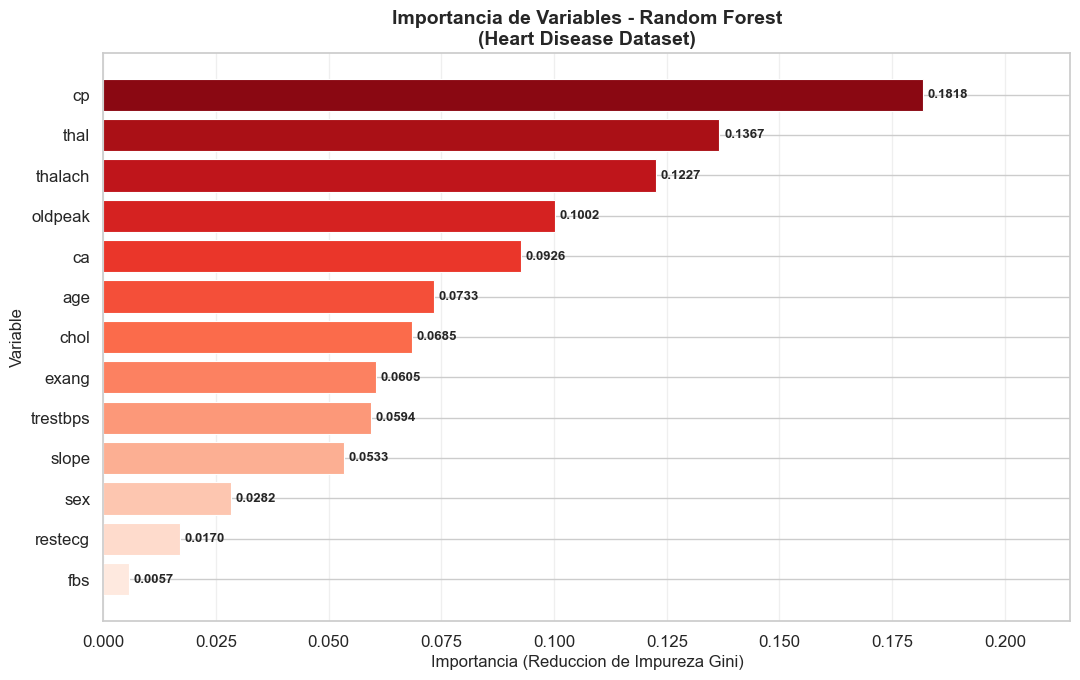

Top 3 variables mas importantes: ['cp', 'thal', 'thalach']


In [27]:
# Grafica de Importancia de Variables (horizontal, ordenada)

colores = sns.color_palette('Reds_r', n_colors=len(importancias_df))

plt.figure(figsize=(11, 7))
barras = plt.barh(
    importancias_df['Variable'][::-1],
    importancias_df['Importancia'][::-1],
    color=colores[::-1],
    edgecolor='white',
    linewidth=0.8
)

for barra, valor in zip(barras, importancias_df['Importancia'][::-1]):
    plt.text(
        barra.get_width() + 0.001,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.4f}',
        va='center', ha='left', fontsize=9.5, fontweight='bold'
    )

plt.xlabel('Importancia (Reduccion de Impureza Gini)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Importancia de Variables - Random Forest\n(Heart Disease Dataset)',
          fontsize=14, fontweight='bold')
plt.xlim(0, importancias_df['Importancia'].max() * 1.18)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top3 = importancias_df.head(3)['Variable'].tolist()
print(f'Top 3 variables mas importantes: {top3}')

## Seccion 11 - Prediccion Final

In [28]:
# ============================================================
# SECCION 11: PREDICCION CON NUEVOS DATOS
# ============================================================
#
# Simulamos 2 nuevos pacientes.
# Los datos pasan exactamente por el mismo pipeline entrenado:
#   imputer -> scaler -> RandomForestClassifier
#
# PACIENTE 1: Perfil de riesgo alto (probable enfermedad)
#   Hombre 62 anyos, dolor asintomatico, presion elevada,
#   colesterol elevado, frecuencia cardiaca baja.
#
# PACIENTE 2: Perfil de riesgo bajo (probable sano)
#   Mujer 45 anyos, sin angina, presion normal,
#   colesterol normal, frecuencia cardiaca alta.

nuevos_pacientes = pd.DataFrame([
    {
        'age': 62, 'sex': 1, 'cp': 3, 'trestbps': 145, 'chol': 233,
        'fbs': 0, 'restecg': 2, 'thalach': 150, 'exang': 0,
        'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 2
    },
    {
        'age': 45, 'sex': 0, 'cp': 1, 'trestbps': 120, 'chol': 180,
        'fbs': 0, 'restecg': 0, 'thalach': 180, 'exang': 0,
        'oldpeak': 0.0, 'slope': 2, 'ca': 0, 'thal': 2
    }
], columns=X_train.columns)

print('Datos de los nuevos pacientes:')
print(nuevos_pacientes.to_string())

# Prediccion de clase (el pipeline aplica imputer->scaler->clf)
clases_predichas = pipeline_rf.predict(nuevos_pacientes)

# Prediccion de probabilidades
probabilidades = pipeline_rf.predict_proba(nuevos_pacientes)

print('\n' + '=' * 55)
print('     RESULTADOS - NUEVOS PACIENTES')
print('=' * 55)

for idx, (clase, probs) in enumerate(zip(clases_predichas, probabilidades), start=1):
    diagnostico = 'CON Enfermedad Cardiaca' if clase == 1 else 'SIN Enfermedad Cardiaca'
    print(f'\n  Paciente {idx}:')
    print(f'    Clase predicha:                  {clase} -> {diagnostico}')
    print(f'    Probabilidad Sin Enfermedad (0): {probs[0]*100:.2f}%')
    print(f'    Probabilidad Con Enfermedad (1): {probs[1]*100:.2f}%')

print('\n' + '=' * 55)
print('Predicciones realizadas exitosamente a traves del pipeline.')

Datos de los nuevos pacientes:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
0   62    1   3       145   233    0        2      150      0      2.3      0   0     2
1   45    0   1       120   180    0        0      180      0      0.0      2   0     2

     RESULTADOS - NUEVOS PACIENTES

  Paciente 1:
    Clase predicha:                  1 -> CON Enfermedad Cardiaca
    Probabilidad Sin Enfermedad (0): 32.55%
    Probabilidad Con Enfermedad (1): 67.45%

  Paciente 2:
    Clase predicha:                  1 -> CON Enfermedad Cardiaca
    Probabilidad Sin Enfermedad (0): 1.27%
    Probabilidad Con Enfermedad (1): 98.73%

Predicciones realizadas exitosamente a traves del pipeline.


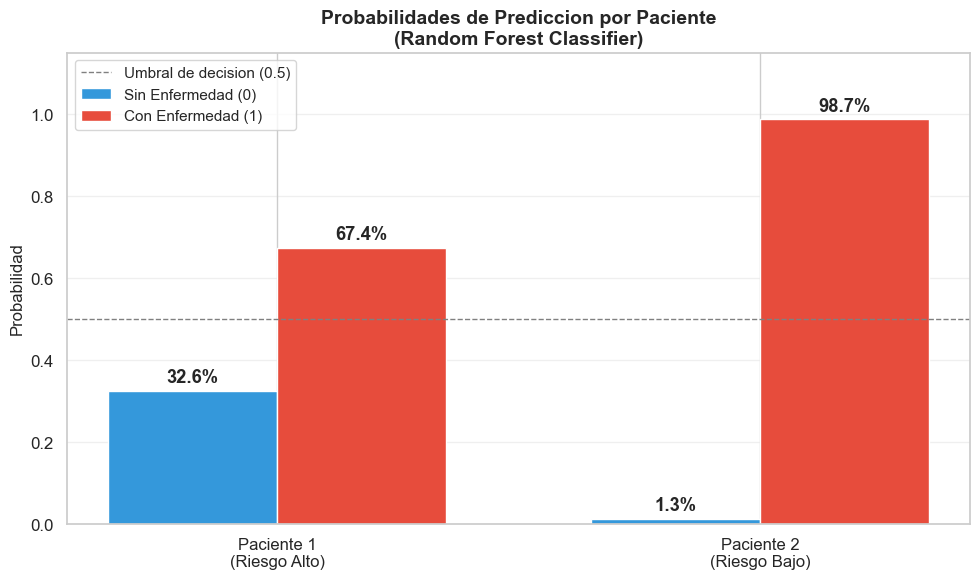

Practica de Machine Learning con Random Forest completada.


In [29]:
# Visualizacion de Probabilidades de Prediccion

nombres_pacientes = ['Paciente 1\n(Riesgo Alto)', 'Paciente 2\n(Riesgo Bajo)']
prob_sin_enfermedad = probabilidades[:, 0]
prob_con_enfermedad = probabilidades[:, 1]

x_pos = np.arange(len(nombres_pacientes))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_0 = ax.bar(
    x_pos - ancho / 2, prob_sin_enfermedad, ancho,
    label='Sin Enfermedad (0)', color='#3498db', edgecolor='white'
)
barras_1 = ax.bar(
    x_pos + ancho / 2, prob_con_enfermedad, ancho,
    label='Con Enfermedad (1)', color='#e74c3c', edgecolor='white'
)

for barra in barras_0:
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.01,
            f'{barra.get_height()*100:.1f}%',
            ha='center', va='bottom', fontweight='bold')
for barra in barras_1:
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.01,
            f'{barra.get_height()*100:.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1,
           label='Umbral de decision (0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_pacientes, fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Probabilidades de Prediccion por Paciente\n(Random Forest Classifier)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Practica de Machine Learning con Random Forest completada.')